---
title: "Central limit theorem - why and when Gaussian distributions appear"
author: "Basics"
date: "2026-05-01"
categories: [statistics, central limit theorem]
format:
  html:
    code-fold: true  # This allows users to click to see the code
    code-summary: "Show the code"
---


## Population distribution, $p(x)$

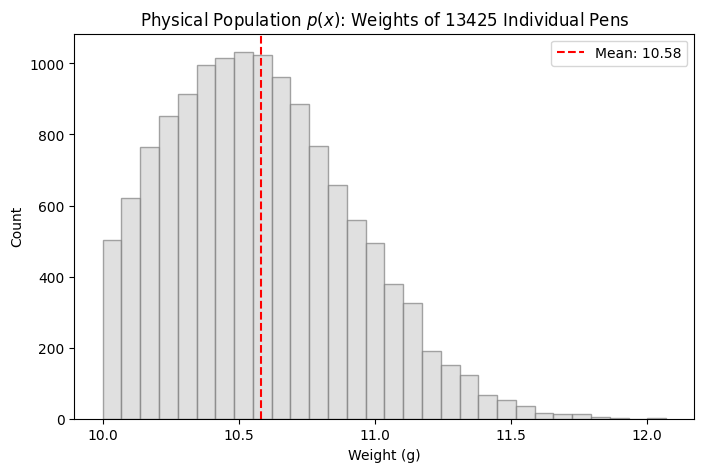

In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create a non-Gaussian population:
#> Bimodal distribution
"""
# 40% are "Light" pens (10g), 60% are "Heavy" pens (15g)
pop_size = 100_000
group1 = np.random.normal(10, 0.8, int(pop_size * 0.4))
group2 = np.random.normal(15, 1.5, int(pop_size * 0.6))
population = np.concatenate([group1, group2])
"""
#> Left truncated Gaussian
mu_factory = 10.5
sigma_factory = 0.4
raw_production = np.random.normal(mu_factory, sigma_factory, 15000)

# 2. Apply Quality Control: Cut everything below 9.2g
threshold = 10.
population = raw_production[raw_production >= threshold]

pop_size = len(population)


plt.figure(figsize=(8, 5))
plt.hist(population, bins=30, color='lightgray', edgecolor='gray', alpha=0.7)
plt.axvline(np.mean(population), color='red', linestyle='--', label=f'Mean: {np.mean(population):.2f}')
plt.title(f"Physical Population $p(x)$: Weights of {pop_size} Individual Pens")
plt.xlabel("Weight (g)")
plt.ylabel("Count")
plt.legend()
plt.show()

## The fallacy: more samples make the distribution Gaussian

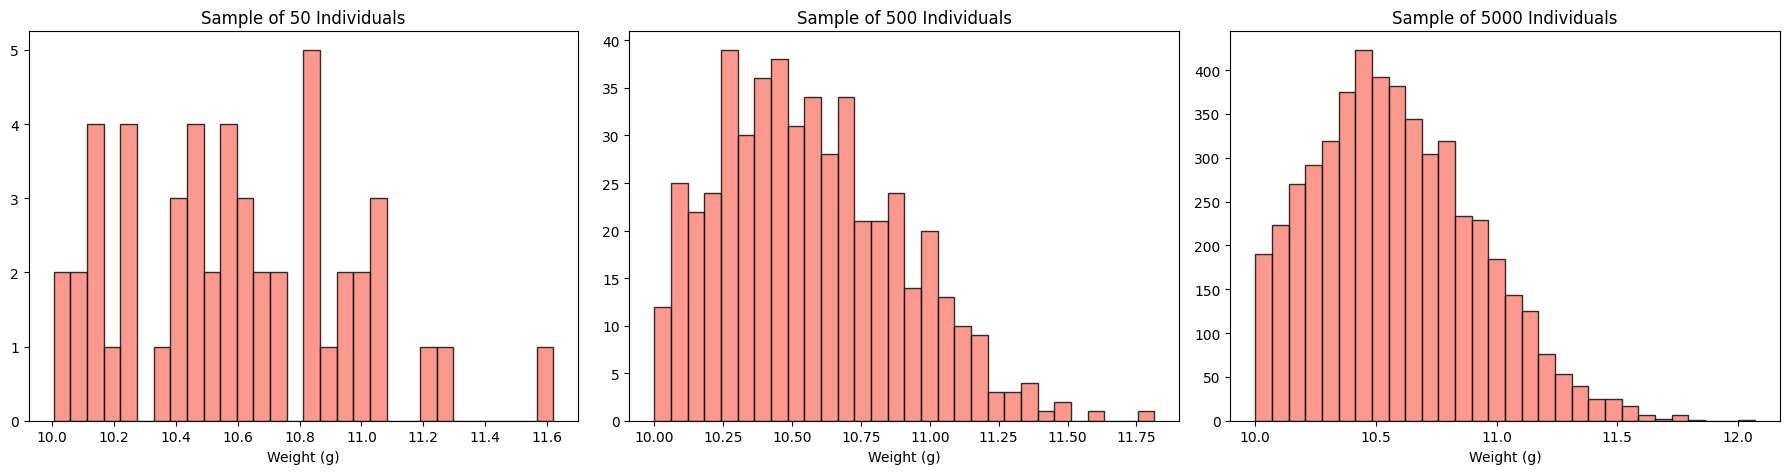

In [37]:
sample_sizes = [50, 500, 5000]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n in enumerate(sample_sizes):
    sample = np.random.choice(population, size=n)
    axes[i].hist(sample, bins=30, color='salmon', edgecolor='black', alpha=0.8)
    axes[i].set_title(f"Sample of {n} Individuals")
    axes[i].set_xlabel("Weight (g)")

plt.suptitle("", fontsize=16)
plt.tight_layout()
plt.show()


## Correct application of the central limit theorem



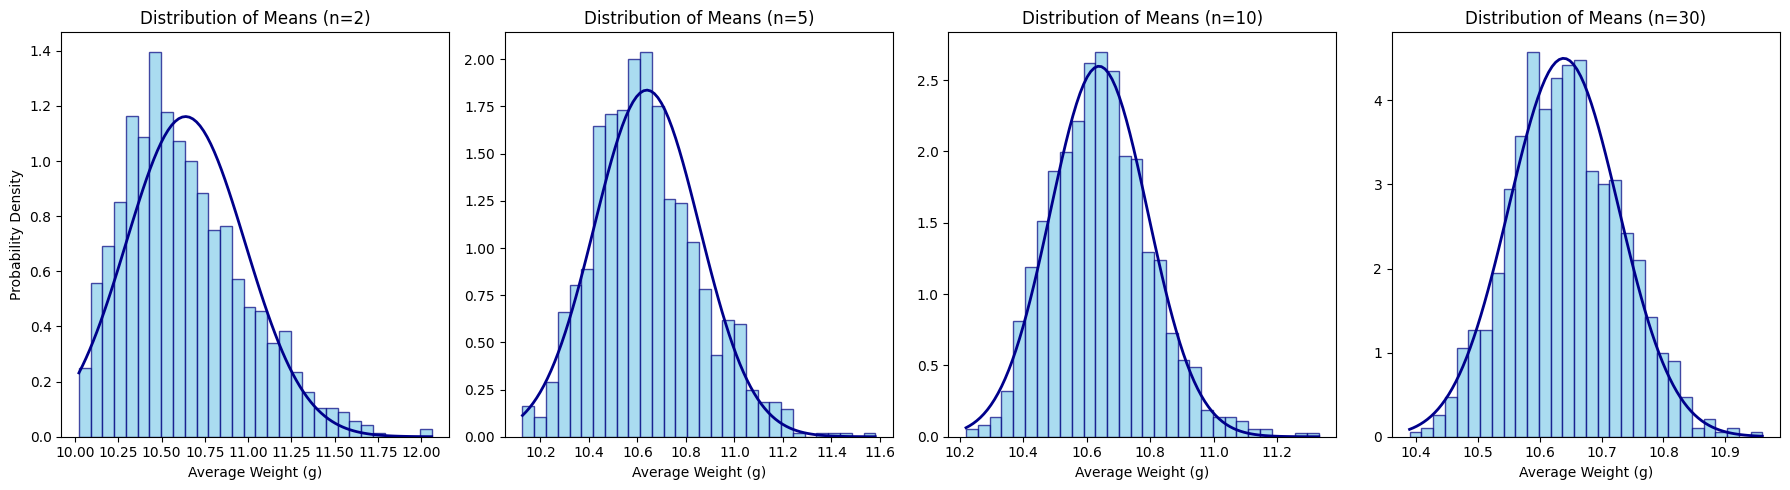

In [32]:
def plot_sampling_distribution(pop, n_values, iterations=1000):
    fig, axes = plt.subplots(1, len(n_values), figsize=(18, 5))
    
    for i, n in enumerate(n_values):
        # The CLT step: calculate the mean of 'n' random pens, 2000 times
        sample_means = [np.mean(np.random.choice(pop, size=n)) for _ in range(iterations)]
        
        # Plotting the means
        axes[i].hist(sample_means, bins=30, color='skyblue', edgecolor='navy', density=True, alpha=0.7)
        
        # Add a theoretical normal curve for comparison
        mu = np.mean(pop)
        sigma_mean = np.std(pop) / np.sqrt(n)
        x = np.linspace(min(sample_means), max(sample_means), 100)
        p = (1 / (sigma_mean * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma_mean)**2)
        axes[i].plot(x, p, color='darkblue', linewidth=2, label='Normal Dist.')
        
        axes[i].set_title(f"Distribution of Means (n={n})")
        axes[i].set_xlabel("Average Weight (g)")
        if i == 0: axes[i].set_ylabel("Probability Density")

plot_sampling_distribution(population, n_values=[2, 5, 10, 30])
plt.tight_layout()
plt.show()


## Links and references

* [Sampling, sampling average, central limit theorem, Gaussian and Student's $t$-distribution](https://basics2022.github.io/bbooks-programming-hs/ch/statistics/sampling.html), in *Introduzione alla programmazione, al calcolo scientifico e alla statistica*
* ...
  